In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [2]:
PHENOTYPE_PATH = os.path.join('..', 'Pediatric_Anxiety_Disorder', 'phenotype')

In [3]:
pheno = pd.read_csv(os.path.join(PHENOTYPE_PATH, 'phenotype.tsv'), sep='\t')
pheno.head()

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,...,DOT_PROBE_BASELINE_BIAS,DOT_PROBE_BASELINE_ABV,DOT_PROBE_BASELINE_DDM_DRIFT_RATE,DOT_PROBE_BASELINE_DDM_BIAS,DOT_PROBE_T2_ACCURACY,DOT_PROBE_T2_MEDIAN_RT_CONGRUENT,DOT_PROBE_T2_MEDIAN_RT_INCONGRUENT,DOT_PROBE_T2_MEDIAN_RT_NEUTRAL,DOT_PROBE_T2_BIAS,DOT_PROBE_T2_ABV
0,sub-020131,1,17,HV,122.0,8.0,1,-1,-1,-1,...,-26.62,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sub-020209,1,16,HV,118.0,8.0,1,-1,-1,-1,...,-5.21,0.07,5.04,0.01,NaN,NaN,NaN,NaN,NaN,NaN
2,sub-020725,1,14,HV,116.0,8.0,1,-1,-1,-1,...,-21.97,0.07,6.57,-0.04,NaN,NaN,NaN,NaN,NaN,NaN
3,sub-021100,-1,11,HV,134.0,8.0,1,-1,-1,-1,...,16.49,0.10,3.71,0.02,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-021214,1,11,HV,130.0,9.0,1,-1,-1,-1,...,4.83,0.06,5.28,-0.01,NaN,NaN,NaN,NaN,NaN,NaN


## Exploratory Data Analysis

In [4]:
pheno.columns

Index(['participant_id', 'sex', 'age_baseline', 'KSADS_MAIN_DIAGNOSIS',
       'WASI_FULL_2_IQ', 'INCOME', 'RACE_WHITE', 'RACE_BLACK', 'RACE_ASIAN',
       'RACE_MULTIPLE', 'ETHNICITY', 'CGAS_BASELINE_SCORE', 'COHORT',
       'SCANNER', 'SCARED_BASELINE_YOUTH_RATING',
       'SCARED_BASELINE_PARENT_RATING', 'PARS_BASELINE_CLINICIAN_RATING',
       'PARS_MID-TREATMENT_CLINICIAN_RATING',
       'PARS_POST-TREATMENT_CLINICIAN_RATING', 'ABMT',
       'NEURAL_EFFICIENCY_BASELINE_FULL_CORRELATIONS',
       'NEURAL_EFFICIENCY_BASELINE_PARTIAL_CORRELATIONS', 'DAYS_BTW_SCANS',
       'NEURAL_EFFICIENCY_T2_FULL_CORRELATIONS',
       'NEURAL_EFFICIENCY_T2_PARTIAL_CORRELATIONS',
       'DOT_PROBE_BASELINE_ACCURACY', 'DOT_PROBE_BASELINE_MEDIAN_RT_CONGRUENT',
       'DOT_PROBE_BASELINE_MEDIAN_RT_INCONGRUENT',
       'DOT_PROBE_BASELINE_MEDIAN_RT_NEUTRAL', 'DOT_PROBE_BASELINE_BIAS',
       'DOT_PROBE_BASELINE_ABV', 'DOT_PROBE_BASELINE_DDM_DRIFT_RATE',
       'DOT_PROBE_BASELINE_DDM_BIAS', 'DOT_PROBE_

In [5]:
print("Number of nulls - \n")
for col in pheno.columns:
    print(f"{col}: {pheno[col].isna().sum()}")

Number of nulls - 

participant_id: 0
sex: 0
age_baseline: 0
KSADS_MAIN_DIAGNOSIS: 0
WASI_FULL_2_IQ: 5
INCOME: 18
RACE_WHITE: 0
RACE_BLACK: 0
RACE_ASIAN: 0
RACE_MULTIPLE: 0
ETHNICITY: 0
CGAS_BASELINE_SCORE: 85
COHORT: 0
SCANNER: 0
SCARED_BASELINE_YOUTH_RATING: 0
SCARED_BASELINE_PARENT_RATING: 0
PARS_BASELINE_CLINICIAN_RATING: 79
PARS_MID-TREATMENT_CLINICIAN_RATING: 81
PARS_POST-TREATMENT_CLINICIAN_RATING: 86
ABMT: 83
NEURAL_EFFICIENCY_BASELINE_FULL_CORRELATIONS: 0
NEURAL_EFFICIENCY_BASELINE_PARTIAL_CORRELATIONS: 0
DAYS_BTW_SCANS: 80
NEURAL_EFFICIENCY_T2_FULL_CORRELATIONS: 81
NEURAL_EFFICIENCY_T2_PARTIAL_CORRELATIONS: 81
DOT_PROBE_BASELINE_ACCURACY: 0
DOT_PROBE_BASELINE_MEDIAN_RT_CONGRUENT: 0
DOT_PROBE_BASELINE_MEDIAN_RT_INCONGRUENT: 0
DOT_PROBE_BASELINE_MEDIAN_RT_NEUTRAL: 0
DOT_PROBE_BASELINE_BIAS: 0
DOT_PROBE_BASELINE_ABV: 0
DOT_PROBE_BASELINE_DDM_DRIFT_RATE: 29
DOT_PROBE_BASELINE_DDM_BIAS: 29
DOT_PROBE_T2_ACCURACY: 78
DOT_PROBE_T2_MEDIAN_RT_CONGRUENT: 81
DOT_PROBE_T2_MEDIAN_RT_INCONG

### Distribution of Sex, Age, & Diagnosis

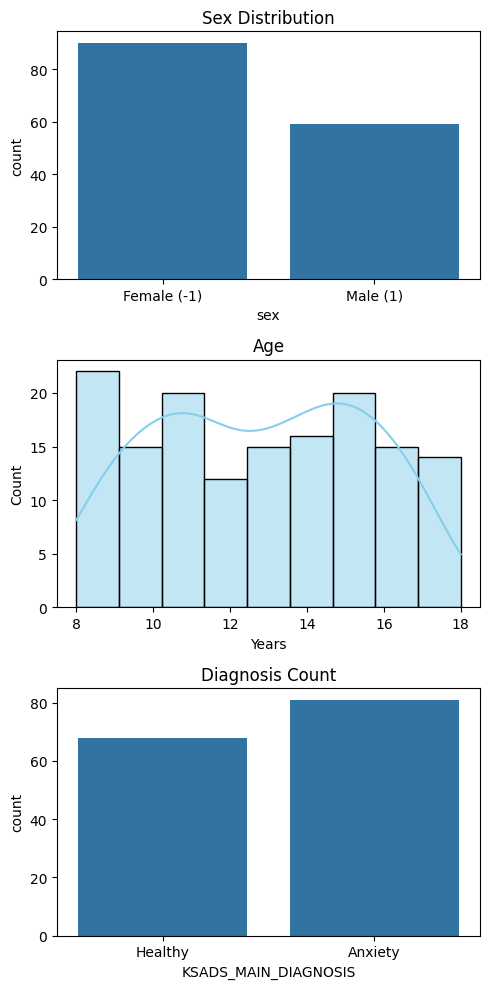

In [6]:
fig, axes = plt.subplots(3,1, figsize=(5,10))

sns.countplot(data=pheno, x='sex', ax=axes[0])
axes[0].set_title('Sex Distribution')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Female (-1)', 'Male (1)'])

sns.histplot(pheno['age_baseline'], bins='auto', kde=True, 
             ax=axes[1], color='skyblue')
axes[1].set_title('Age')
axes[1].set_xlabel('Years')

sns.countplot(data=pheno, x='KSADS_MAIN_DIAGNOSIS', 
              order=['HV', 'ANX'], ax=axes[2])
axes[2].set_title('Diagnosis Count')
axes[2].set_xticks([0,1])
axes[2].set_xticklabels(['Healthy', 'Anxiety'])

plt.tight_layout()
plt.show()

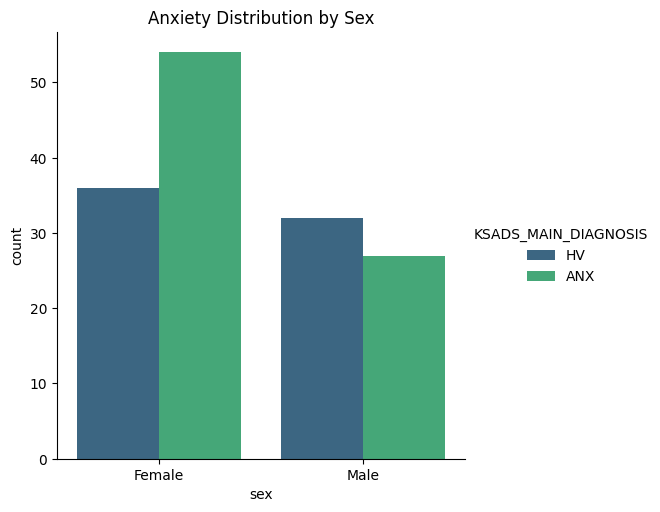

In [7]:
sns.catplot(data=pheno, x='sex', hue='KSADS_MAIN_DIAGNOSIS', 
            kind='count', palette='viridis')
plt.xticks([0,1], ['Female', 'Male'])
plt.title('Anxiety Distribution by Sex')
plt.show()

### Distribution of Race & Ethnicity

In [8]:
race_cols = ['RACE_WHITE', 'RACE_BLACK', 'RACE_ASIAN', 'RACE_MULTIPLE']
race_counts = (pheno[race_cols]==1).sum().reset_index()
race_counts.columns = ['Category', 'Subject_count']
race_counts['Category'] = race_counts['Category'].replace({
    'RACE_WHITE': 'White',
    'RACE_BLACK': 'Black',
    'RACE_ASIAN': 'Asian',
    'RACE_MULTIPLE': 'Multiple_Races'
})

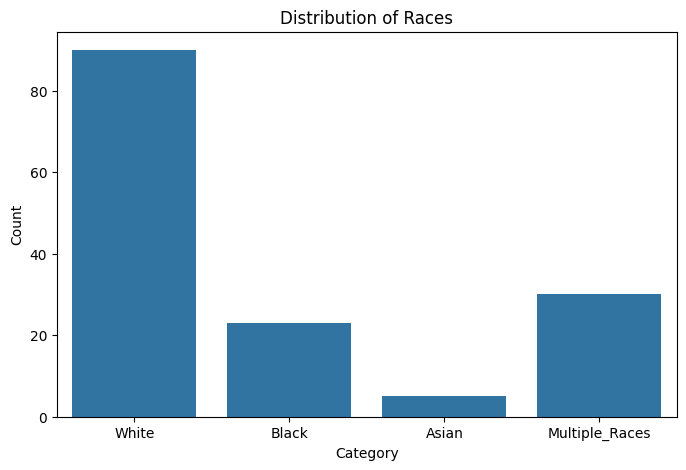

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(data=race_counts, x='Category', y='Subject_count')
plt.title('Distribution of Races')
plt.ylabel('Count')
plt.show()

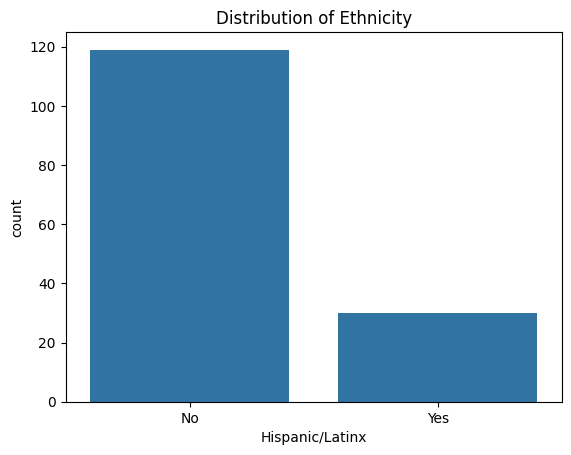

In [10]:
sns.countplot(data=pheno, x='ETHNICITY')
plt.title('Distribution of Ethnicity')
plt.xticks([0,1], ['No', 'Yes'])
plt.xlabel('Hispanic/Latinx')
plt.show()

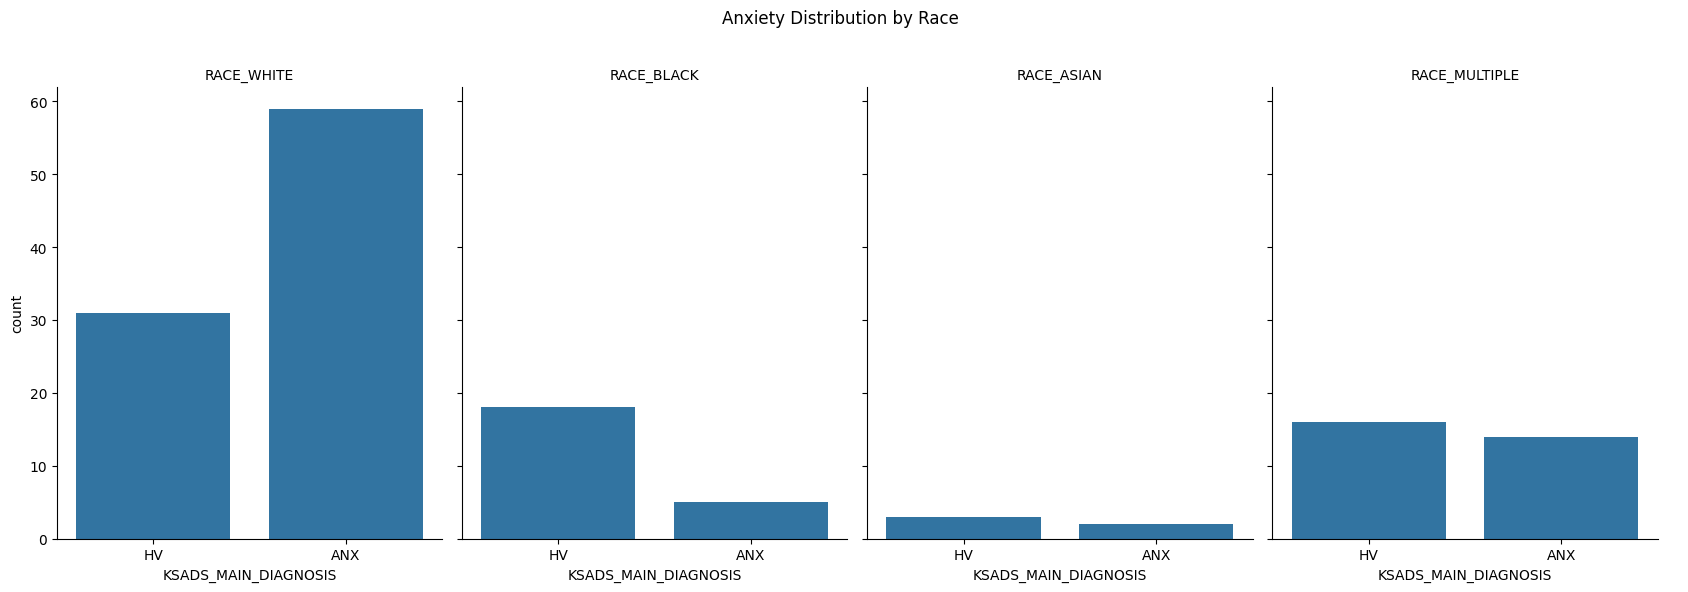

In [11]:
# making every combination of diagnosis and race
diagnosis_by_race = pheno.melt(
    id_vars=['KSADS_MAIN_DIAGNOSIS'],
    value_vars=race_cols,
    var_name='Race',
    value_name='Is_Present'
)
# keeping only true combinations
diagnosis_by_race = diagnosis_by_race[diagnosis_by_race['Is_Present']==1]

plots = sns.catplot(data=diagnosis_by_race, x='KSADS_MAIN_DIAGNOSIS',col='Race',
           kind='count', sharey=True, height=6, aspect=0.7)
plots.set_titles("{col_name}")
plots.fig.suptitle("Anxiety Distribution by Race")
plots.fig.subplots_adjust(top=0.85)
plt.show()

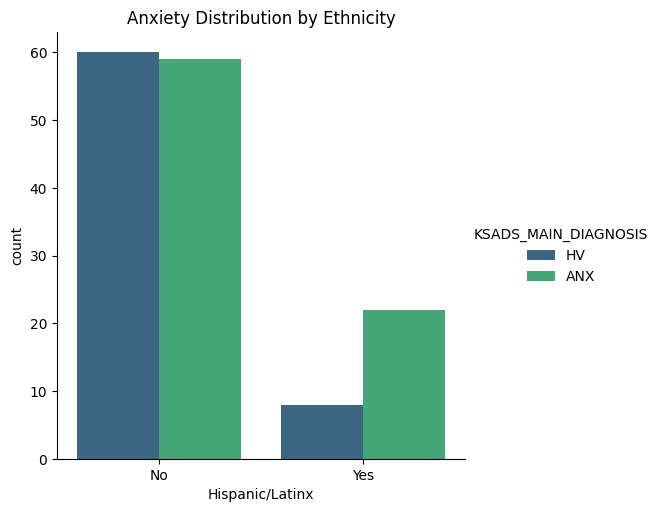

In [12]:
sns.catplot(data=pheno, x='ETHNICITY', hue='KSADS_MAIN_DIAGNOSIS', 
            kind='count', palette='viridis')
plt.xticks([0,1], ['No', 'Yes'])
plt.xlabel('Hispanic/Latinx')
plt.title('Anxiety Distribution by Ethnicity')
plt.show()

### Distribution of SCARED Scores

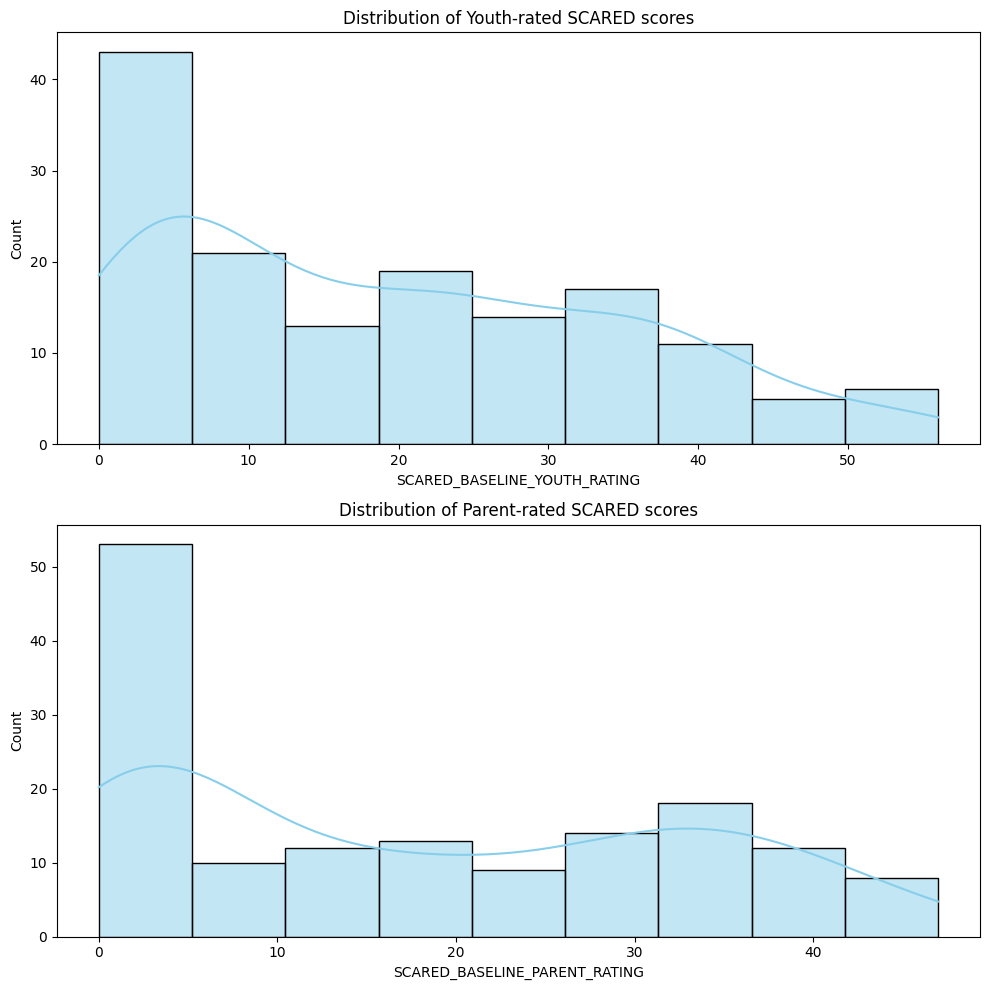

In [13]:
fig, axes = plt.subplots(2,1, figsize=(10,10))

sns.histplot(pheno['SCARED_BASELINE_YOUTH_RATING'], bins='auto', kde=True, 
             ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Youth-rated SCARED scores')

sns.histplot(pheno['SCARED_BASELINE_PARENT_RATING'], bins='auto', kde=True, 
             ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Parent-rated SCARED scores')

plt.tight_layout()
plt.show()

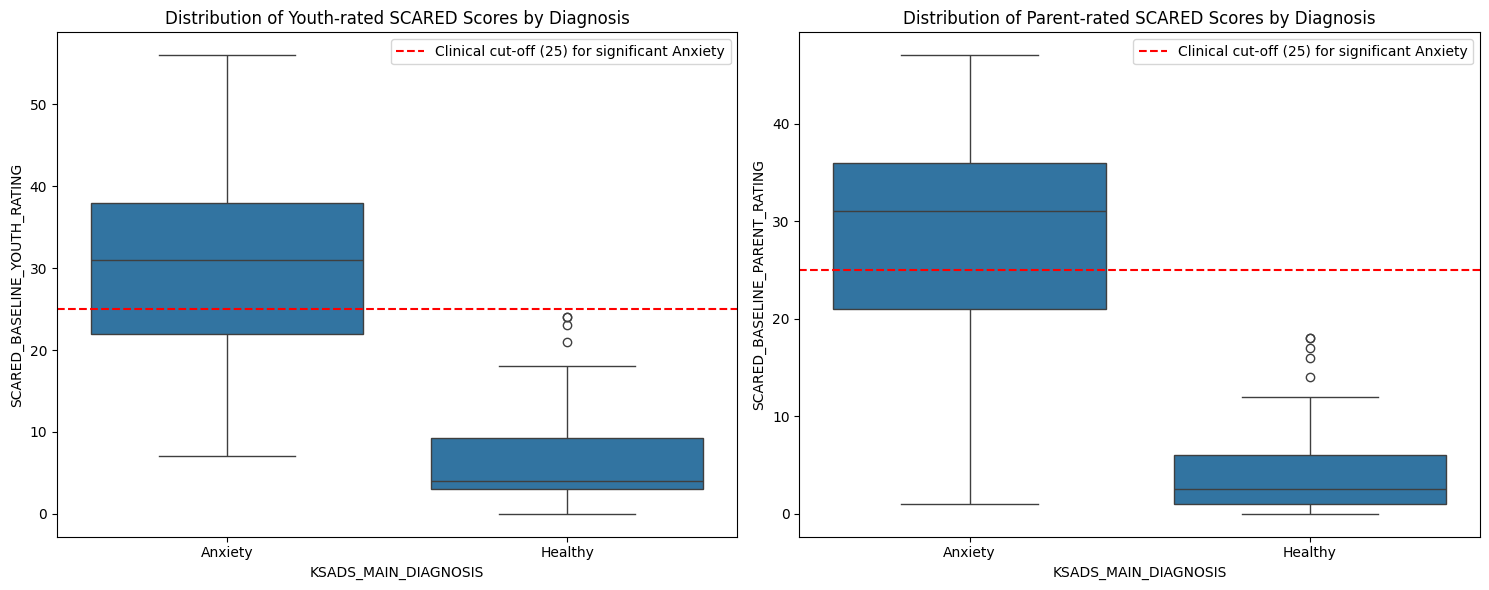

In [14]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

sns.boxplot(data=pheno, x='KSADS_MAIN_DIAGNOSIS', 
            y='SCARED_BASELINE_YOUTH_RATING', order=['ANX', 'HV'], ax=axes[0])
axes[0].set_title('Distribution of Youth-rated SCARED Scores by Diagnosis')

sns.boxplot(data=pheno, x='KSADS_MAIN_DIAGNOSIS', 
            y='SCARED_BASELINE_PARENT_RATING', order=['ANX', 'HV'], ax=axes[1])
axes[1].set_title('Distribution of Parent-rated SCARED Scores by Diagnosis')

for ax in axes:
    ax.axhline(25, color='red', linestyle='--', 
               label='Clinical cut-off (25) for significant Anxiety')
    ax.legend()
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Anxiety', 'Healthy'])

plt.tight_layout()
plt.show()

* The Anxiety group has significantly higher median scores than the Healthy group in both parent and youth ratings. This proves that the presence of anxiety is clearly visible in this behavioral data.
* The red line at 25 is the standard clinical threshold for a likely anxiety disorder.
  - Most of the Anxiety subjects are above the 25-point line.
  - All of the Healthy subjects are well below the line. However, there are a few outliers in the Healthy group, which are kids who scored near or above 20 but were still labelled as 'Healthy' by clinicans (via KSADS).
* The scores for the healthy group have much lesser spread compared to those of anxiety group. This suggests the severity varies significantly regardless of sharing a clinical diagnosis.

In [15]:
display(pheno[['SCARED_BASELINE_YOUTH_RATING','SCARED_BASELINE_PARENT_RATING']].corr())

,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING
SCARED_BASELINE_YOUTH_RATING,1.000000,0.692813
SCARED_BASELINE_PARENT_RATING,0.692813,1.000000


There exists somewhat strong correlation between the youth-rated and parent-rated SCARED scores, but it's not perfect. If the SCARED scores are to be included as input features, it will be important to use them separately instead of averaging them.

## Handling Missing Values

* Handle missing values for `WASI_FULL_2_IQ` and `INCOME`. All other demographic features have no nulls. `COHORT` and `SCANNER` columns also have no missing values. All of these features will be used as confounds for 2nd Level GLM.
* `SCARED_BASELINE_YOUTH_RATING` and `SCARED_BASELINE_PARENT_RATING` have no missing values. These can be used as additional non-brain features for the final diagnosis predictions. Alternatively, these can also be kept as targets instead of being used as input to the final model.
* `KSADS_MAIN_DIAGNOSIS` has no nulls and will be one of the main final targets.
* `CGAS_BASELINE_SCORE`, `PARS_BASELINE_CLINICIAN_RATING`, `PARS_MID-TREATMENT_CLINICIAN_RATING`, `PARS_POST-TREATMENT_CLINICIAN_RATING`, `ABMT`, and `DAYS_BTW_SCANS` have more than half the records have NULL values.
  * Eliminate `ABMT`, as it can only serve as an input feature but has too many missing values.
  * The 2nd session of fMRI scans weren't taken for all subjects, and so, only 1st session scans will be used in this project. Thus, `DAYS_BTW_SCANS` feature is meaningless and unnecessary.
  * `CGAS_BASELINE_SCORE` and `PARS_BASELINE_CLINICIAN_RATING` can be used as targets for the final model with a semi-supervised learning approach. Hence, retain these.
  * Since, there are no fMRI scans for during or after treatments, eliminate `PARS_MID-TREATMENT_CLINICIAN_RATING` and `PARS_POST-TREATMENT_CLINICIAN_RATING`. 
* All other columns are derived features that are not necessary for the project.

In [16]:
imp_columns = ['participant_id', 'sex', 'age_baseline', 'KSADS_MAIN_DIAGNOSIS', 
               'WASI_FULL_2_IQ', 'INCOME', 'RACE_WHITE', 'RACE_BLACK', 
               'RACE_ASIAN', 'RACE_MULTIPLE', 'ETHNICITY', 'COHORT', 'SCANNER', 
               'SCARED_BASELINE_YOUTH_RATING', 'SCARED_BASELINE_PARENT_RATING', 
               'CGAS_BASELINE_SCORE', 'PARS_BASELINE_CLINICIAN_RATING']

In [17]:
print(imp_columns)

['participant_id', 'sex', 'age_baseline', 'KSADS_MAIN_DIAGNOSIS', 'WASI_FULL_2_IQ', 'INCOME', 'RACE_WHITE', 'RACE_BLACK', 'RACE_ASIAN', 'RACE_MULTIPLE', 'ETHNICITY', 'COHORT', 'SCANNER', 'SCARED_BASELINE_YOUTH_RATING', 'SCARED_BASELINE_PARENT_RATING', 'CGAS_BASELINE_SCORE', 'PARS_BASELINE_CLINICIAN_RATING']


In [18]:
pheno_ = pheno[imp_columns].copy()
pheno_.head()

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING
0,sub-020131,1,17,HV,122.0,8.0,1,-1,-1,-1,-1,1,1,4.0,7.2,NaN,NaN
1,sub-020209,1,16,HV,118.0,8.0,1,-1,-1,-1,-1,1,1,23.0,17.0,NaN,NaN
2,sub-020725,1,14,HV,116.0,8.0,1,-1,-1,-1,-1,1,1,3.0,0.0,NaN,NaN
3,sub-021100,-1,11,HV,134.0,8.0,1,-1,-1,-1,-1,1,1,8.0,1.0,NaN,NaN
4,sub-021214,1,11,HV,130.0,9.0,1,-1,-1,-1,-1,1,1,16.0,1.0,NaN,NaN


In [19]:
pheno_.loc[pheno_['WASI_FULL_2_IQ'].isna()]

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING
106,sub-023986,1,13,HV,NaN,7.0,-1,1,-1,-1,-1,-1,-1,0.0,1.0,NaN,NaN
137,sub-024197,-1,11,HV,NaN,NaN,1,-1,-1,-1,-1,-1,1,1.0,4.0,NaN,NaN
138,sub-024198,1,10,HV,NaN,NaN,1,-1,-1,-1,-1,-1,-1,3.1,4.0,NaN,NaN
139,sub-024212,1,11,HV,NaN,6.0,-1,1,-1,-1,-1,-1,1,6.0,18.0,NaN,NaN
144,sub-024270,-1,13,HV,NaN,8.0,-1,-1,-1,1,1,-1,-1,15.0,7.0,NaN,NaN


In [20]:
pheno_.loc[pheno_['INCOME'].isna()]

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING
24,sub-022536,-1,14,HV,101.0,NaN,-1,-1,-1,1,-1,1,1,2.0,3.0,NaN,NaN
55,sub-023342,-1,15,HV,111.0,NaN,1,-1,-1,-1,-1,-1,1,0.0,1.0,NaN,NaN
64,sub-023432,-1,10,HV,118.0,NaN,-1,-1,-1,1,-1,-1,-1,4.0,7.0,NaN,NaN
70,sub-023501,-1,13,ANX,123.0,NaN,1,-1,-1,-1,1,-1,-1,37.0,20.0,41.0,15.0
74,sub-023545,1,16,HV,97.0,NaN,1,-1,-1,-1,-1,-1,-1,8.0,1.0,NaN,NaN
75,sub-023559,-1,13,HV,109.0,NaN,-1,-1,-1,1,-1,-1,1,4.0,10.3,NaN,NaN
83,sub-023631,1,13,ANX,109.0,NaN,1,-1,-1,-1,1,-1,1,22.0,11.3,41.0,17.0
97,sub-023892,-1,9,HV,131.0,NaN,1,-1,-1,-1,-1,-1,-1,5.0,8.0,NaN,NaN
100,sub-023925,-1,8,ANX,129.0,NaN,-1,-1,-1,1,1,-1,1,26.0,43.0,61.0,13.0
103,sub-023972,-1,8,ANX,117.0,NaN,1,-1,-1,-1,-1,-1,1,24.0,24.6,NaN,13.0


### MICE (Multivariate Imputation by Chained Equations)
This is an iterative method that handles missing data by creating multiple imputations based on other variables in the dataset. It models each missing variable as a function of others (e.g., linear regression for continuous, logistic for categorical), cycling through variables until convergence to create robust, filled datasets.

Use demographic data only (`sex`, `age_baseline`, `WASI_FULL_2_IQ`, `INCOME`, `RACE_WHITE`, `RACE_BLACK`, `RACE_ASIAN`, `RACE_MULTIPLE`, `ETHNICITY`) as features for imputation.

Exclude all others to avoid data leakage.

In [21]:
imputation_features = ['sex', 'age_baseline', 'WASI_FULL_2_IQ', 'INCOME', 'RACE_WHITE', 'RACE_BLACK', 'RACE_ASIAN', 'RACE_MULTIPLE', 'ETHNICITY']

In [22]:
imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_data = imputer.fit_transform(pheno_[imputation_features])

In [23]:
pheno_[imputation_features] = imputed_data
pheno_.head()

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING
0,sub-020131,1.0,17.0,HV,122.0,8.0,1.0,-1.0,-1.0,-1.0,-1.0,1,1,4.0,7.2,NaN,NaN
1,sub-020209,1.0,16.0,HV,118.0,8.0,1.0,-1.0,-1.0,-1.0,-1.0,1,1,23.0,17.0,NaN,NaN
2,sub-020725,1.0,14.0,HV,116.0,8.0,1.0,-1.0,-1.0,-1.0,-1.0,1,1,3.0,0.0,NaN,NaN
3,sub-021100,-1.0,11.0,HV,134.0,8.0,1.0,-1.0,-1.0,-1.0,-1.0,1,1,8.0,1.0,NaN,NaN
4,sub-021214,1.0,11.0,HV,130.0,9.0,1.0,-1.0,-1.0,-1.0,-1.0,1,1,16.0,1.0,NaN,NaN


In [24]:
pheno_[pheno['WASI_FULL_2_IQ'].isna()]

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING
106,sub-023986,1.0,13.0,HV,107.753026,7.000000,-1.0,1.0,-1.0,-1.0,-1.0,-1,-1,0.0,1.0,NaN,NaN
137,sub-024197,-1.0,11.0,HV,114.396298,8.221516,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,1.0,4.0,NaN,NaN
138,sub-024198,1.0,10.0,HV,117.107516,8.414268,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,3.1,4.0,NaN,NaN
139,sub-024212,1.0,11.0,HV,108.314025,6.000000,-1.0,1.0,-1.0,-1.0,-1.0,-1,1,6.0,18.0,NaN,NaN
144,sub-024270,-1.0,13.0,HV,111.985615,8.000000,-1.0,-1.0,-1.0,1.0,1.0,-1,-1,15.0,7.0,NaN,NaN


In [25]:
pheno_[pheno['INCOME'].isna()]

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING
24,sub-022536,-1.0,14.0,HV,101.000000,6.788715,-1.0,-1.0,-1.0,1.0,-1.0,1,1,2.0,3.0,NaN,NaN
55,sub-023342,-1.0,15.0,HV,111.000000,8.048816,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,0.0,1.0,NaN,NaN
64,sub-023432,-1.0,10.0,HV,118.000000,7.264947,-1.0,-1.0,-1.0,1.0,-1.0,-1,-1,4.0,7.0,NaN,NaN
70,sub-023501,-1.0,13.0,ANX,123.000000,8.391023,1.0,-1.0,-1.0,-1.0,1.0,-1,-1,37.0,20.0,41.0,15.0
74,sub-023545,1.0,16.0,HV,97.000000,7.820238,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,8.0,1.0,NaN,NaN
75,sub-023559,-1.0,13.0,HV,109.000000,6.991445,-1.0,-1.0,-1.0,1.0,-1.0,-1,1,4.0,10.3,NaN,NaN
83,sub-023631,1.0,13.0,ANX,109.000000,8.186676,1.0,-1.0,-1.0,-1.0,1.0,-1,1,22.0,11.3,41.0,17.0
97,sub-023892,-1.0,9.0,HV,131.000000,8.640446,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,5.0,8.0,NaN,NaN
100,sub-023925,-1.0,8.0,ANX,129.000000,7.584842,-1.0,-1.0,-1.0,1.0,1.0,-1,1,26.0,43.0,61.0,13.0
103,sub-023972,-1.0,8.0,ANX,117.000000,8.352301,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,24.0,24.6,NaN,13.0


In [26]:
pheno_['INCOME'] = pheno_['INCOME'].round().clip(1,9)
pheno_[pheno['INCOME'].isna()]

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING
24,sub-022536,-1.0,14.0,HV,101.000000,7.0,-1.0,-1.0,-1.0,1.0,-1.0,1,1,2.0,3.0,NaN,NaN
55,sub-023342,-1.0,15.0,HV,111.000000,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,0.0,1.0,NaN,NaN
64,sub-023432,-1.0,10.0,HV,118.000000,7.0,-1.0,-1.0,-1.0,1.0,-1.0,-1,-1,4.0,7.0,NaN,NaN
70,sub-023501,-1.0,13.0,ANX,123.000000,8.0,1.0,-1.0,-1.0,-1.0,1.0,-1,-1,37.0,20.0,41.0,15.0
74,sub-023545,1.0,16.0,HV,97.000000,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,8.0,1.0,NaN,NaN
75,sub-023559,-1.0,13.0,HV,109.000000,7.0,-1.0,-1.0,-1.0,1.0,-1.0,-1,1,4.0,10.3,NaN,NaN
83,sub-023631,1.0,13.0,ANX,109.000000,8.0,1.0,-1.0,-1.0,-1.0,1.0,-1,1,22.0,11.3,41.0,17.0
97,sub-023892,-1.0,9.0,HV,131.000000,9.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,5.0,8.0,NaN,NaN
100,sub-023925,-1.0,8.0,ANX,129.000000,8.0,-1.0,-1.0,-1.0,1.0,1.0,-1,1,26.0,43.0,61.0,13.0
103,sub-023972,-1.0,8.0,ANX,117.000000,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,24.0,24.6,NaN,13.0


### Validation of Imputation

In [27]:
# Validation check for IQ
print(f"Original IQ Mean: {pheno['WASI_FULL_2_IQ'].mean():.2f}")
print(f"Imputed IQ Mean: {pheno_['WASI_FULL_2_IQ'].mean():.2f}")

Original IQ Mean: 111.74
Imputed IQ Mean: 111.75


In [28]:
# Validation check for Income
print(f"Original Income Median: {pheno['INCOME'].median()}")
print(f"Imputed Income Median: {pheno_['INCOME'].median()}")

Original Income Median: 8.0
Imputed Income Median: 8.0


In [29]:
# Compare descriptive statistics
stats_comparison = pd.DataFrame({
    'Original IQ': pheno['WASI_FULL_2_IQ'].describe(),
    'Imputed IQ': pheno_['WASI_FULL_2_IQ'].describe(),
    'Original Income': pheno['INCOME'].describe(),
    'Imputed Income': pheno_['INCOME'].describe()
})

display(stats_comparison)

,Original IQ,Imputed IQ,Original Income,Imputed Income
count,144.000000,149.000000,131.000000,149.000000
mean,111.743056,111.748701,7.778626,7.771812
std,12.554634,12.358125,1.453326,1.376054
min,82.000000,82.000000,2.000000,2.000000
25%,102.750000,104.000000,8.000000,8.000000
50%,112.000000,112.000000,8.000000,8.000000
75%,118.000000,118.000000,9.000000,9.000000
max,143.000000,143.000000,9.000000,9.000000


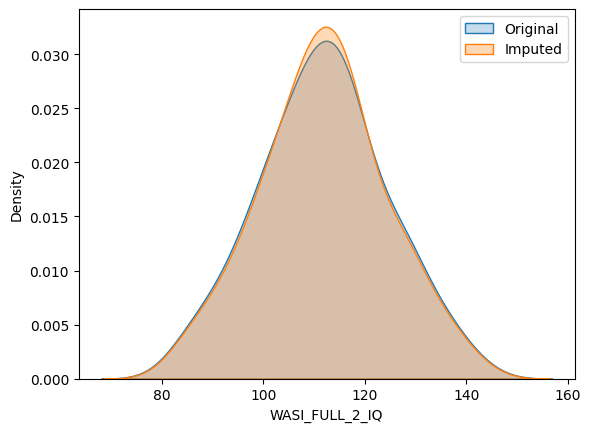

In [30]:
# Visualizing IQ
sns.kdeplot(pheno['WASI_FULL_2_IQ'].dropna(), label='Original', fill=True)
sns.kdeplot(pheno_['WASI_FULL_2_IQ'], label='Imputed', fill=True, alpha=0.3)
plt.legend()
plt.show()

* The peak of the curve hasn't moved left or right, so there's no significant shift in the mean of the data.
* The width of the curves match, so variance of the data has also been preserved.
* The tails of the orange curve didn't change, so, the imputer has not created any unrealistic IQ scores.

In [31]:
# Compare the most common income level
print(f"Original Income Mode: {pheno['INCOME'].mode()[0]}")
print(f"Imputed Income Mode: {pheno_['INCOME'].mode()[0]}")

Original Income Mode: 8.0
Imputed Income Mode: 8.0


In [32]:
pheno_.isna().sum()

participant_id                     0
sex                                0
age_baseline                       0
KSADS_MAIN_DIAGNOSIS               0
WASI_FULL_2_IQ                     0
INCOME                             0
RACE_WHITE                         0
RACE_BLACK                         0
RACE_ASIAN                         0
RACE_MULTIPLE                      0
ETHNICITY                          0
COHORT                             0
SCANNER                            0
SCARED_BASELINE_YOUTH_RATING       0
SCARED_BASELINE_PARENT_RATING      0
CGAS_BASELINE_SCORE               85
PARS_BASELINE_CLINICIAN_RATING    79
dtype: int64

### The "Missingness" Indicators
After filling the missing values for `INCOME` and `WASI_FULL_2_IQ` create new binary columns called `INCOME_IS_MISSING` and `IQ_IS_MISSING`. Mark it 1 for the subjects filled and -1 for the rest. Including this in the final analysis allows the model to account for any potential bias introduced by the imputation itself.

In [33]:
pheno_['IQ_IS_MISSING'] = np.where(pheno['WASI_FULL_2_IQ'].isnull(), 1, -1)
pheno_['INCOME_IS_MISSING'] = np.where(pheno['INCOME'].isnull(), 1, -1)

In [34]:
pheno_[pheno['WASI_FULL_2_IQ'].isna()]

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING,IQ_IS_MISSING,INCOME_IS_MISSING
106,sub-023986,1.0,13.0,HV,107.753026,7.0,-1.0,1.0,-1.0,-1.0,-1.0,-1,-1,0.0,1.0,NaN,NaN,1,-1
137,sub-024197,-1.0,11.0,HV,114.396298,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,1.0,4.0,NaN,NaN,1,1
138,sub-024198,1.0,10.0,HV,117.107516,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,3.1,4.0,NaN,NaN,1,1
139,sub-024212,1.0,11.0,HV,108.314025,6.0,-1.0,1.0,-1.0,-1.0,-1.0,-1,1,6.0,18.0,NaN,NaN,1,-1
144,sub-024270,-1.0,13.0,HV,111.985615,8.0,-1.0,-1.0,-1.0,1.0,1.0,-1,-1,15.0,7.0,NaN,NaN,1,-1


In [35]:
pheno_[pheno['INCOME'].isna()]

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING,IQ_IS_MISSING,INCOME_IS_MISSING
24,sub-022536,-1.0,14.0,HV,101.000000,7.0,-1.0,-1.0,-1.0,1.0,-1.0,1,1,2.0,3.0,NaN,NaN,-1,1
55,sub-023342,-1.0,15.0,HV,111.000000,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,0.0,1.0,NaN,NaN,-1,1
64,sub-023432,-1.0,10.0,HV,118.000000,7.0,-1.0,-1.0,-1.0,1.0,-1.0,-1,-1,4.0,7.0,NaN,NaN,-1,1
70,sub-023501,-1.0,13.0,ANX,123.000000,8.0,1.0,-1.0,-1.0,-1.0,1.0,-1,-1,37.0,20.0,41.0,15.0,-1,1
74,sub-023545,1.0,16.0,HV,97.000000,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,8.0,1.0,NaN,NaN,-1,1
75,sub-023559,-1.0,13.0,HV,109.000000,7.0,-1.0,-1.0,-1.0,1.0,-1.0,-1,1,4.0,10.3,NaN,NaN,-1,1
83,sub-023631,1.0,13.0,ANX,109.000000,8.0,1.0,-1.0,-1.0,-1.0,1.0,-1,1,22.0,11.3,41.0,17.0,-1,1
97,sub-023892,-1.0,9.0,HV,131.000000,9.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,5.0,8.0,NaN,NaN,-1,1
100,sub-023925,-1.0,8.0,ANX,129.000000,8.0,-1.0,-1.0,-1.0,1.0,1.0,-1,1,26.0,43.0,61.0,13.0,-1,1
103,sub-023972,-1.0,8.0,ANX,117.000000,8.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,24.0,24.6,NaN,13.0,-1,1


In [36]:
pheno_.to_csv(os.path.join(PHENOTYPE_PATH, 'phenotype_preprocessed.tsv'), 
                   sep='\t', index=False)